# Shopify Stock Data Understanding, Cleaning & Exploratory Analysis

This notebook uses simple Python and pandas steps to understand Shopify stock data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the data

In [2]:
df = pd.read_csv('/content/shopify_stock.csv')
df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


## 2. Understand the data

In [3]:
df.shape

(2469, 7)

In [4]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2469 entries, 0 to 2468
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       2469 non-null   object 
 1   open       2469 non-null   float64
 2   high       2469 non-null   float64
 3   low        2469 non-null   float64
 4   close      2469 non-null   float64
 5   adj_close  2469 non-null   float64
 6   volume     2469 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 135.2+ KB


In [6]:
df.isnull().sum()

date         0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64

In [7]:
df[['open', 'high', 'low', 'close', 'volume']].describe()

,open,high,low,close,volume
count,2469.000000,2469.000000,2469.000000,2469.000000,2.469000e+03
mean,48.464345,49.505495,47.347795,48.456613,1.657049e+07
std,43.633916,44.470235,42.642546,43.573362,1.436909e+07
min,1.939000,1.985000,1.848000,1.933000,1.039000e+06
25%,10.479000,10.635000,10.275000,10.450000,8.098000e+06
50%,35.640999,36.879002,34.655998,35.874001,1.275860e+07
75%,76.080002,77.169998,74.589996,75.800003,2.060200e+07
max,171.800003,176.291794,168.509506,169.059998,2.089590e+08


## 3. Clean the data

In [8]:
df['date'] = pd.to_datetime(df['date'], utc=True)

price_columns = ['open', 'high', 'low', 'close', 'volume']
for col in price_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=price_columns)
df = df.drop_duplicates(subset='date')
df = df.sort_values('date').reset_index(drop=True)

df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 04:00:00+00:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 04:00:00+00:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 04:00:00+00:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 04:00:00+00:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 04:00:00+00:00,2.755,2.774,2.648,2.745,2.745,4000000


## 4. Calculate daily price change

In [9]:
df['price_delta'] = df['close'] - df['open']
df['daily_return'] = (df['price_delta'] / df['open']) * 100
df[['date', 'open', 'close', 'price_delta', 'daily_return']].head(10)

,date,open,close,price_delta,daily_return
0,2015-05-21 04:00:00+00:00,2.800,2.568,-0.232,-8.285710
1,2015-05-22 04:00:00+00:00,2.607,2.831,0.224,8.592250
2,2015-05-26 04:00:00+00:00,2.980,2.965,-0.015,-0.503359
3,2015-05-27 04:00:00+00:00,3.067,2.750,-0.317,-10.335830
4,2015-05-28 04:00:00+00:00,2.755,2.745,-0.010,-0.362985
5,2015-05-29 04:00:00+00:00,2.725,2.720,-0.005,-0.183482
6,2015-06-01 04:00:00+00:00,2.720,2.733,0.013,0.477942
7,2015-06-02 04:00:00+00:00,2.747,2.695,-0.052,-1.892976
8,2015-06-03 04:00:00+00:00,2.676,2.744,0.068,2.541100
9,2015-06-04 04:00:00+00:00,2.742,2.678,-0.064,-2.334067


## 5. Look at price changes

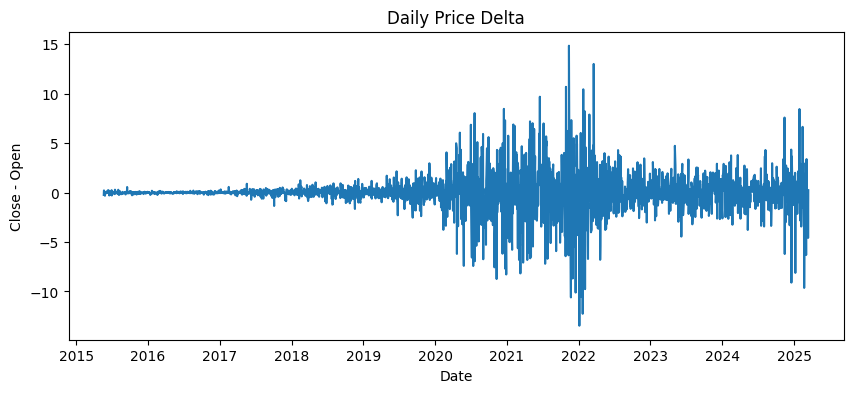

In [10]:
plt.figure(figsize=(10,4))
plt.plot(df['date'], df['price_delta'])
plt.xlabel('Date')
plt.ylabel('Close - Open')
plt.title('Daily Price Delta')
plt.show()

## 6. Trading volume trends

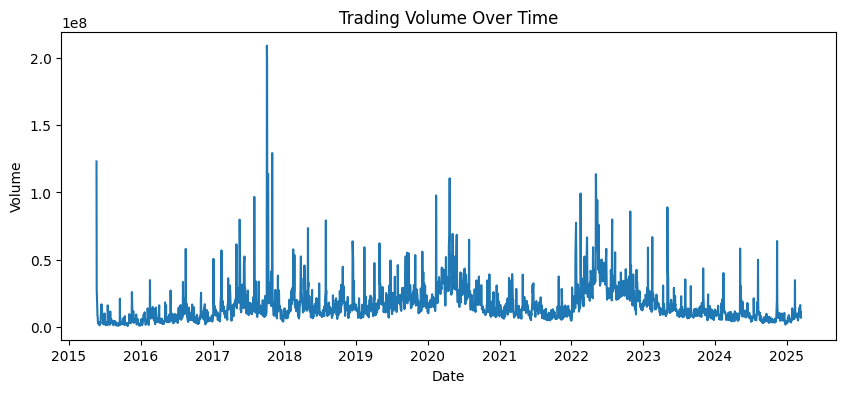

In [11]:
plt.figure(figsize=(10,4))
plt.plot(df['date'], df['volume'])
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Trading Volume Over Time')
plt.show()

## 7. Find anomalous trading days

We use the IQR method. Very high volume values above the upper limit are treated as anomalies.

In [12]:
Q1 = df['volume'].quantile(0.25)
Q3 = df['volume'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

anomalies = df[df['volume'] > upper_limit]
anomalies[['date', 'volume']].sort_values('volume', ascending=False).head(10)

,date,volume
598,2017-10-04 04:00:00+00:00,208959000
599,2017-10-05 04:00:00+00:00,197807000
617,2017-10-31 04:00:00+00:00,129271000
0,2015-05-21 04:00:00+00:00,123039000
602,2017-10-10 04:00:00+00:00,113732000
1752,2022-05-05 04:00:00+00:00,113608000
1237,2020-04-21 04:00:00+00:00,110507000
1753,2022-05-06 04:00:00+00:00,102696000
1698,2022-02-16 05:00:00+00:00,99250000
1190,2020-02-12 05:00:00+00:00,97794000


In [13]:
print('Upper volume limit:', upper_limit)
print('Number of anomalous days:', len(anomalies))

Upper volume limit: 39358000.0
Number of anomalous days: 136


## 8. Return distribution

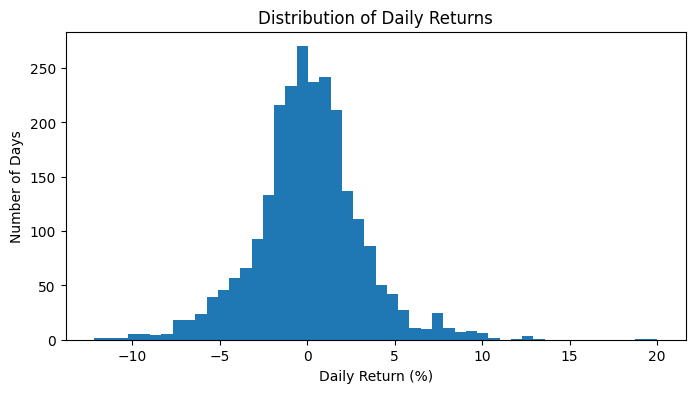

In [14]:
plt.figure(figsize=(8,4))
plt.hist(df['daily_return'], bins=50)
plt.xlabel('Daily Return (%)')
plt.ylabel('Number of Days')
plt.title('Distribution of Daily Returns')
plt.show()

## 9. Mean, variance and standard deviation

In [15]:
mean_return = df['daily_return'].mean()
variance_return = df['daily_return'].var()
std_return = df['daily_return'].std()

print('Mean:', mean_return)
print('Variance:', variance_return)
print('Standard Deviation:', std_return)

Mean: 0.08640631099421993
Variance: 9.733081984179552
Standard Deviation: 3.1197887723657756


## 10. Final summary

In [16]:
print('Total trading days:', len(df))
print('Average daily return:', round(mean_return, 4), '%')
print('Return variance:', round(variance_return, 4))
print('Return standard deviation:', round(std_return, 4), '%')
print('Anomalous volume days:', len(anomalies))

Total trading days: 2469
Average daily return: 0.0864 %
Return variance: 9.7331
Return standard deviation: 3.1198 %
Anomalous volume days: 136
